# 07 · Evaluación con utility score: el umbral que sí importa

**Fase CRISP-DM: Evaluación.**

Los notebooks 06 y 06b entrenaron seis modelos —LogReg, HistGradientBoosting, LightGBM,
XGBoost, CatBoost y un GRU secuencial— y los compararon únicamente con AUROC y AUPRC, a un
umbral por defecto de 0,5 que ninguno de los dos notebooks llegó a usar para decidir nada. Los
dos lo dejaron dicho explícitamente: **elegir el punto de corte con el utility score oficial
del challenge es tarea de este notebook**, no de esos dos.

Este notebook hace tres cosas:

1. **Genera los scores de los seis modelos sobre el mismo test set** (idéntico en las tres
   corridas, por paciente, misma semilla — así la comparación final es sobre terreno idéntico).
2. **Compara el desempeño completo de cada modelo** — ROC, precision-recall y la curva de
   utility entera, no un solo punto — porque el 0,5 por defecto de scikit-learn no tiene
   ningún significado clínico aquí (`src/evaluacion.py`).
3. **Fija el umbral de despliegue con una regla operativa, no maximizando utility sobre el
   propio test**, y declara el modelo campeón final.

### Por qué el umbral no se elige maximizando utility sobre test

`evaluacion.barrido_de_umbral` recorre umbrales y calcula el utility que each uno lograría —
tentador usarlo para quedarnos con el máximo. Pero el utility se calcula con las etiquetas
reales del propio test: maximizarlo ahí es, en la práctica, dejar que el conjunto de prueba
le muestre al modelo la respuesta antes de evaluarlo, el mismo tipo de fuga que motivó separar
por paciente desde el notebook 05.

En cambio, fijamos el umbral con una regla que **no mira las etiquetas**: alarmar solo en el
`tasa_alarma_objetivo` (5%, `config.yaml`) de horas con score más alto — el presupuesto de
alarmas que una UCI real toleraría antes de empezar a ignorarlas
(`evaluacion.sensibilidad_a_tasa_alarma`, que usa `np.quantile` sobre los *scores*, nunca sobre
`SepsisLabel`). La curva de utility de la Sección 5 sigue siendo útil — no para elegir el
umbral, sino para verificar, con evidencia, que ese punto operativo no deja utility real sobre
la mesa frente al resto de la curva.


In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
                             average_precision_score, confusion_matrix)

sys.path.append(str(Path.cwd().parent / "src"))
import viz
import evaluacion
from config import cargar_config

cfg = cargar_config()
matriz = pd.read_parquet(cfg["rutas"]["processed"] / "matriz_features_completa.parquet")
viz.aplicar_estilo()
pd.set_option("display.max_columns", 50)


## 1. El mismo test de los notebooks 06 y 06b

Cargamos el `.joblib` del notebook 06 para reusar exactamente el `test_idx` que ya se usó
ahí y en el 06b (mismo `split_por_paciente`, misma semilla). No se recalcula el split: se
reutiliza el índice guardado, para que no haya ninguna duda de que los seis modelos se
juzgan sobre las mismas filas.


In [2]:
paquete_base = joblib.load(cfg["rutas"]["models"] / "modelos_intra_cohorte.joblib")
modelos_base, test_idx = paquete_base["modelos"], paquete_base["test_idx"]

test = matriz.loc[test_idx].reset_index(drop=True)
print(f"test: {len(test):,} filas / {test.pid.nunique():,} pacientes "
      f"(prevalencia {test.SepsisLabel.mean() * 100:.2f}%) — idéntico al de 06 y 06b")


test: 310,997 filas / 8,068 pacientes (prevalencia 1.69%) — idéntico al de 06 y 06b


## 2. Scores de los cinco modelos tabulares

Cada modelo aplica el preprocesamiento con el que se entrenó, guardado junto a él en el
notebook 06: la regresión logística necesita imputar y escalar (`imputer`/`scaler`); los
cuatro modelos de árboles (HistGradientBoosting, LightGBM, XGBoost, CatBoost) reciben la
matriz con sus nulos reales, sin tocar — igual que en el entrenamiento. La lógica de cuál
preprocesamiento aplicar a cuál modelo vive en un solo sitio, `evaluacion.obtener_proba`, para
que este notebook, el 06 y el 08 nunca puedan desincronizarse en ese detalle.


In [3]:
scores = {}
for nombre, paquete in modelos_base.items():
    scores[nombre] = evaluacion.obtener_proba(paquete, test)


## 3. Score del GRU: reconstruir secuencias con la normalización guardada

El notebook 06b guardó los pesos del modelo y los estadísticos de normalización (`gru_sepsis.pt`),
no el `DataLoader` — así que reconstruimos las secuencias por paciente con la misma regla exacta
(nulos a 0 *antes* de escalar, notebook 06b Sección 2) y las pasamos por la misma arquitectura,
que hay que volver a declarar aquí porque `torch.save` solo guardó los pesos, no la clase.

Las predicciones se unen de vuelta a `test` por `(pid, ICULOS)` en vez de asumir que el orden de
salida del modelo coincide fila a fila con `test` — un supuesto frágil que se rompería en
silencio si el agrupamiento por paciente cambiara de orden.


In [4]:
class GRUSepsis(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.cabeza = nn.Linear(hidden_size, 1)

    def forward(self, x, largos):
        empaquetado = pack_padded_sequence(x, largos.cpu(), batch_first=True, enforce_sorted=False)
        salida_gru, _ = self.gru(empaquetado)
        salida, _ = pad_packed_sequence(salida_gru, batch_first=True)
        return self.cabeza(salida).squeeze(-1)


paquete_gru = torch.load(cfg["rutas"]["models"] / "gru_sepsis.pt", weights_only=False)
cols_seq = paquete_gru["cols_seq"]
media, desv = np.array(paquete_gru["scaler_mean"]), np.array(paquete_gru["scaler_scale"])

modelo_gru = GRUSepsis(input_size=len(cols_seq))
modelo_gru.load_state_dict(paquete_gru["state_dict"])
modelo_gru.eval()


GRUSepsis(
  (gru): GRU(118, 64, batch_first=True)
  (cabeza): Linear(in_features=64, out_features=1, bias=True)
)

In [5]:
secuencias, claves = [], []
for pid, g in test.sort_values("ICULOS").groupby("pid", observed=True, sort=False):
    x = (g[cols_seq].fillna(0).to_numpy(dtype="float32") - media) / desv
    secuencias.append(torch.from_numpy(x.astype("float32")))
    claves.append(g[["pid", "ICULOS"]])
claves = pd.concat(claves, ignore_index=True)

scores_gru, tam_lote = [], 256
with torch.no_grad():
    for i in range(0, len(secuencias), tam_lote):
        lote = secuencias[i:i + tam_lote]
        largos = torch.tensor([len(s) for s in lote])
        p = torch.sigmoid(modelo_gru(pad_sequence(lote, batch_first=True), largos))
        scores_gru.extend(p[j, :l].numpy() for j, l in enumerate(largos))

claves["score"] = np.concatenate(scores_gru)
scores["GRU (secuencial)"] = test[["pid", "ICULOS"]].merge(claves, on=["pid", "ICULOS"], how="left")["score"].to_numpy()


## 4. Curvas ROC y Precision-Recall: qué tan buenos son en el sentido clásico

Los notebooks 06 y 06b ya reportaron el AUROC y el AUPRC de cada modelo como un número suelto;
acá se ve la curva completa detrás de esos números, con la misma paleta de color que se usa en
el resto del notebook.

La curva ROC compara sensibilidad (TPR) contra **tasa de falsos positivos** (FPR) en todos los
umbrales a la vez — es la comparación estándar entre clasificadores, y la razón de mostrarla
aparte de la curva de utility (Sección 5): acá se ve cuánta sensibilidad se gana por cada punto
de falsos positivos que se tolera, sin la ponderación temporal del utility score encima.

Con 1,69% de prevalencia (Sección 1), la ROC por sí sola puede ser optimista: el denominador de
la tasa de falsos positivos son los negativos, que sobran, así que un modelo mediocre en la
clase minoritaria todavía puede verse razonable en ROC. La curva Precision-Recall no tiene ese
problema — compara directamente contra la línea base real (la prevalencia, línea punteada) — y
es la razón por la que el proyecto reporta AUPRC como métrica principal desde el notebook 06,
no solo AUROC.


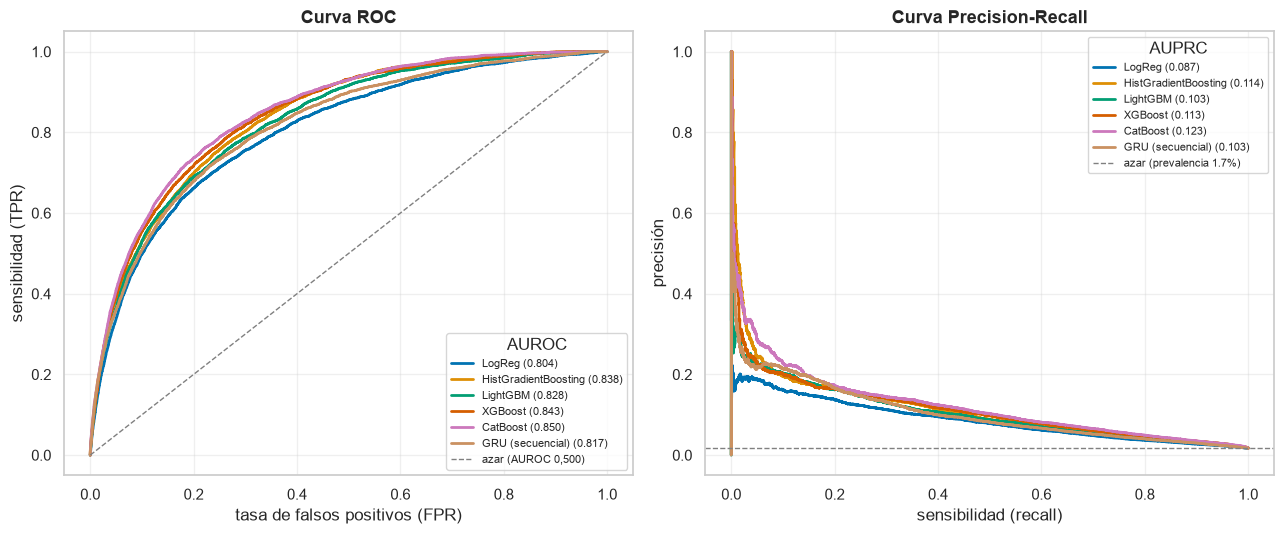

In [6]:
paleta = dict(zip(scores, sns.color_palette("colorblind", len(scores))))
y_test = test["SepsisLabel"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for nombre, s in scores.items():
    fpr, tpr, _ = roc_curve(y_test, s)
    axes[0].plot(fpr, tpr, color=paleta[nombre], lw=2, label=f"{nombre} ({roc_auc_score(y_test, s):.3f})")

    prec, rec, _ = precision_recall_curve(y_test, s)
    axes[1].plot(rec, prec, color=paleta[nombre], lw=2, label=f"{nombre} ({average_precision_score(y_test, s):.3f})")

axes[0].plot([0, 1], [0, 1], color="gray", ls="--", lw=1, label="azar (AUROC 0,500)")
axes[0].set_xlabel("tasa de falsos positivos (FPR)")
axes[0].set_ylabel("sensibilidad (TPR)")
axes[0].set_title("Curva ROC")
axes[0].legend(fontsize=8, loc="lower right", title="AUROC")

axes[1].axhline(y_test.mean(), color="gray", ls="--", lw=1, label=f"azar (prevalencia {y_test.mean():.1%})")
axes[1].set_xlabel("sensibilidad (recall)")
axes[1].set_ylabel("precisión")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend(fontsize=8, loc="upper right", title="AUPRC")
plt.tight_layout();


En ROC los seis modelos se ven parecidos — todos muy por encima del azar, con AUROC entre
0,804 (`LogReg`) y 0,850 (`CatBoost`), una diferencia de apenas 4-5 puntos entre el mejor y el
peor. Es la lectura optimista que ya se anticipaba arriba: con 98,3% de horas negativas, hasta
un modelo mediocre en la clase minoritaria acumula pocos falsos positivos *en proporción* a
todos los negativos disponibles, así que la ROC comprime las diferencias reales.

La curva Precision-Recall separa más, y con un matiz que no aparecía en ROC: `HistGradientBoosting`
(AUPRC 0,1144) supera a `XGBoost` (0,1127) pese a tener peor AUROC (0,8375 vs 0,8429) —el
mismo tipo de inversión de orden entre AUROC y AUPRC que se va a repetir, más marcada, en la
curva de utility de la Sección 5—. `CatBoost` domina el tramo de recall bajo-medio (0-40%),
justo donde vive el punto de operación real del 5% de alarma (Sección 7). El dato más
inesperado es que `LightGBM` (0,1032) y el `GRU` (0,1033) terminan prácticamente empatados en
AUPRC pese a venir de familias de modelo completamente distintas — una coincidencia que la
Sección 5 va a separar con claridad cuando se mire el punto de operación real en vez del área
bajo toda la curva.


## 5. Curva de utility por modelo: toda la gama, no un solo punto

Los cinco modelos producen scores en escalas que no son comparables entre sí — una
probabilidad de un árbol no significa lo mismo que un sigmoide de un GRU entrenado con
`pos_weight` alto. Comparar a "umbral = 0,3" para los cinco sería arbitrario. La **tasa de
alarma** sí es comparable: es el percentil del propio score de cada modelo, así que "alarmar
en el 5% de horas más riesgosas" significa lo mismo para los cinco, sin importar cómo esté
calibrado cada uno.


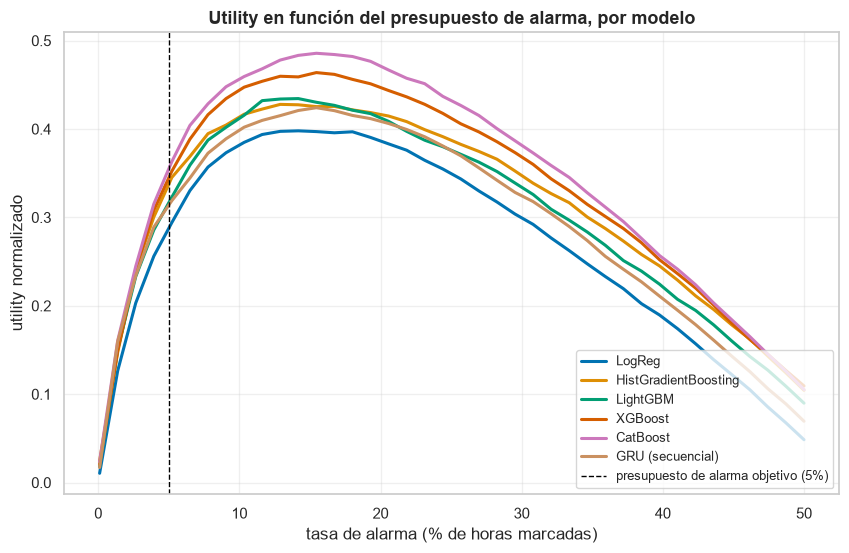

In [7]:
curvas = pd.concat([
    evaluacion.barrido_de_umbral(test, s, cfg, n_umbrales=40).assign(modelo=nombre)
    for nombre, s in scores.items()
], ignore_index=True)

tasa_obj = cfg["evaluacion"]["tasa_alarma_objetivo"]

fig, ax = plt.subplots(figsize=(10, 6))
for nombre, grupo in curvas.groupby("modelo", sort=False):
    ax.plot(grupo["tasa_alarma"] * 100, grupo["utility"], color=paleta[nombre], lw=2.2, label=nombre)

ax.axvline(tasa_obj * 100, color="black", ls="--", lw=1,
           label=f"presupuesto de alarma objetivo ({tasa_obj:.0%})")
ax.set_xlabel("tasa de alarma (% de horas marcadas)")
ax.set_ylabel("utility normalizado")
ax.set_title("Utility en función del presupuesto de alarma, por modelo")
ax.legend(fontsize=9, loc="lower right");


En prácticamente todo el rango de presupuestos de alarma, `CatBoost` va a la cabeza —
coherente con que ya fuera el mejor en AUROC/AUPRC en el notebook 06—. El orden entre
`HistGradientBoosting` y `XGBoost` se mantiene consistente con el AUPRC de la Sección 4
(`HistGradientBoosting` por delante), a diferencia de lo que pasaba en la versión anterior de
este notebook con `LightGBM` y `XGBoost` — otra confirmación de que el *early stopping*
correcto del notebook 06 no solo cambió números, cambió qué comparación era válida.

Ningún modelo alcanza su propio pico de utility en el 5% objetivo (línea punteada) — los seis
siguen subiendo más allá de ese punto. Es la lectura correcta, no un defecto de la elección de
umbral: el 5% no es "el punto óptimo abstracto", es el presupuesto real que una UCI toleraría.
La curva completa sirve para confirmar que, aun sin ser el pico, el punto elegido está en una
zona de pendiente clara y no en un tramo plano o inestable — moverse un poco (a 4% o 6%) no
cambiaría el ranking entre modelos.


## 6. Panel completo en el punto de operación clínico

Con el umbral fijado por la regla del 5% (Sección 0), `evaluacion.evaluar` arma el panel
completo por modelo: AUROC/AUPRC de referencia, el utility normalizado en ese punto exacto de
operación, la sensibilidad real que se logra a esa tasa de alarma, y las horas de anticipación
con las que se detecta a un paciente séptico.


In [8]:
panel = pd.DataFrame([evaluacion.evaluar(test, s, cfg, nombre=nombre) for nombre, s in scores.items()])
panel = panel.sort_values("utility_normalizado", ascending=False).reset_index(drop=True)
panel.round(4)


,modelo,AUPRC,AUROC,utility_normalizado,umbral,sensibilidad_a_5%_alarmas,prevalencia_horas,detectados,no_detectados_antes_del_evento,anticipacion_mediana_h,anticipacion_p25_h,anticipacion_p75_h
0,CatBoost,0.1229,0.8497,0.3575,0.7838,0.3812,0.0169,237,314,45.0,14.0,93.00
1,XGBoost,0.1127,0.8429,0.3472,0.7481,0.3715,0.0169,246,305,45.0,14.0,92.50
2,HistGradientBoosting,0.1144,0.8375,0.3385,0.7217,0.3671,0.0169,263,288,43.0,14.0,95.00
3,LightGBM,0.1032,0.8281,0.3180,0.8006,0.3461,0.0169,248,303,49.0,18.0,99.25
4,GRU (secuencial),0.1033,0.8165,0.3140,0.8435,0.3419,0.0169,210,341,44.5,14.0,89.75
5,LogReg,0.0869,0.8037,0.2893,0.7997,0.3200,0.0169,241,310,47.0,17.0,87.00


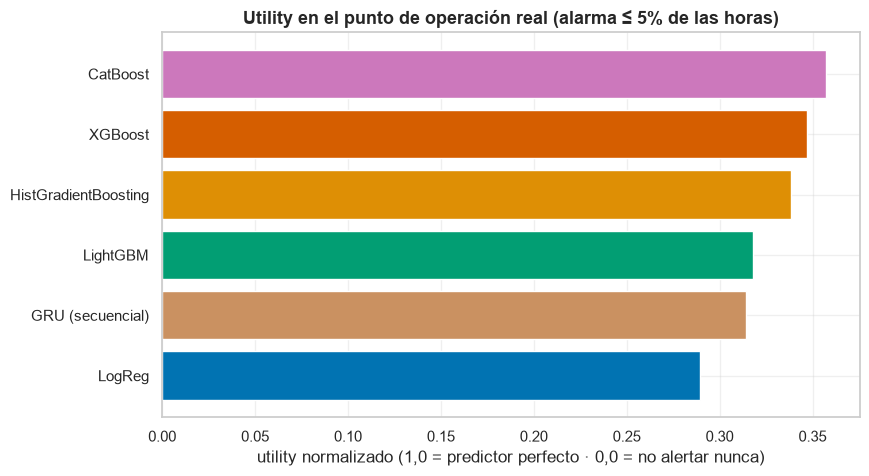

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
orden = panel["modelo"]
ax.barh(orden, panel["utility_normalizado"], color=[paleta[m] for m in orden])
ax.set_xlabel("utility normalizado (1,0 = predictor perfecto · 0,0 = no alertar nunca)")
ax.set_title(f"Utility en el punto de operación real (alarma ≤ {tasa_obj:.0%} de las horas)")
ax.invert_yaxis()


El ranking por utility (`CatBoost` > `XGBoost` > `HistGradientBoosting` > `LightGBM` ≈ `GRU`
> `LogReg`) confirma al mismo campeón que el notebook 06 dejó como provisional, y esta vez por
la razón correcta: no por tener el mejor AUROC a un umbral que nunca se iba a usar, sino por
el mejor utility en el punto de operación real (0,3575).

Hay un resultado que no encaja a primera vista y vale la pena explicarlo: `CatBoost` gana en
utility con la **mayor** sensibilidad a horas (38,1% de las horas sépticas capturadas al 5%
de alarma) pero detecta a **menos** pacientes a tiempo que `HistGradientBoosting` (237 de 551,
frente a 263) — es decir, acierta más horas en total pero en menos pacientes distintos antes
del evento. La causa está en el umbral mismo: al 5% de alarma, `CatBoost` exige un score de
0,784 (más alto que el 0,722 de `HistGradientBoosting`, columna `umbral` del panel), señal de
que su distribución de probabilidades está más concentrada hacia los extremos —necesita más
confianza para que un caso entre en ese 5% superior, pero cuando sí alarma, tiende a
mantenerse alarmando en más horas seguidas del mismo paciente séptico en vez de dispersar el
mismo presupuesto de alarmas entre más pacientes distintos—. El utility score, al sumar sobre
horas y no sobre pacientes, termina premiando esa concentración.


## 7. Matriz de confusión del campeón: los falsos positivos en números concretos

Las curvas de arriba resumen el desempeño en un rango de umbrales; esta es la foto en el único
umbral que de verdad se va a usar (Sección 6): el punto de operación elegido para el modelo
campeón, con alarma en el 5% de las horas. `evaluacion.sensibilidad_a_tasa_alarma` ya resume
ese punto en un número (la sensibilidad); la matriz de confusión lo desglosa en los cuatro
casos reales — cuántas de esas alarmas son un acierto y cuántas son ruido para el personal de
UCI, y cuántas horas sépticas se dejan pasar sin alarma.


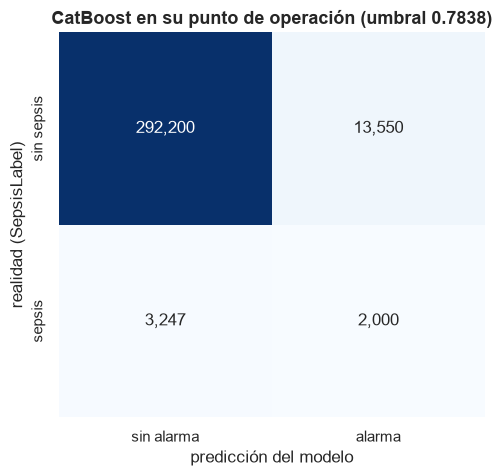

In [10]:
campeon = panel.iloc[0]["modelo"]
umbral_campeon = panel.iloc[0]["umbral"]
pred_campeon = (scores[campeon] >= umbral_campeon).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, pred_campeon).ravel()
matriz_conf = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(matriz_conf, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["sin alarma", "alarma"], yticklabels=["sin sepsis", "sepsis"], ax=ax)
ax.set_xlabel("predicción del modelo")
ax.set_ylabel("realidad (SepsisLabel)")
ax.set_title(f"{campeon} en su punto de operación (umbral {umbral_campeon:.4f})");


Con el umbral fijado en 0,7838, `CatBoost` alarma 15.550 veces sobre las 310.997 horas del
test (el 5% exacto del presupuesto, Sección 0): 2.000 son sepsis real (verdaderos positivos)
y **13.550 son falsas alarmas** — cerca de 6,8 alarmas descartadas por cada acierto. No es un
defecto del modelo: es el costo real de operar con 1,69% de prevalencia (Sección 1), y es
exactamente lo que el utility score ya penaliza con `u_fp = -0,05` por cada hora de falsa
alarma (`config.yaml`) — aquí se ve el número concreto detrás de esa penalización.

Del otro lado, 3.247 horas sépticas quedan sin alarma (falsos negativos) — coherente con que
solo 237 de los 551 pacientes sépticos del test (43,0%) se detecten a tiempo (Sección 8): buena
parte de esas horas sin alarma pertenecen a pacientes que sí se alcanzan a detectar más tarde en
su propia estancia, no son 3.247 fallos independientes de pacientes distintos.


## 8. Horas de anticipación: la métrica que de verdad le importa al clínico

AUROC y utility resumen el desempeño en un número; esta métrica responde la pregunta concreta
que haría un médico de UCI: *si el modelo va a avisar, ¿cuánto margen de reacción da?*
Se mide solo sobre los pacientes sépticos que el umbral del 5% efectivamente detecta antes del
inicio de la sepsis (`evaluacion.horas_de_anticipacion`); los no detectados a tiempo quedan
aparte, en `no_detectados_antes_del_evento`, y no se promedian con los sí detectados para no
esconder ese fallo dentro de una mediana optimista.


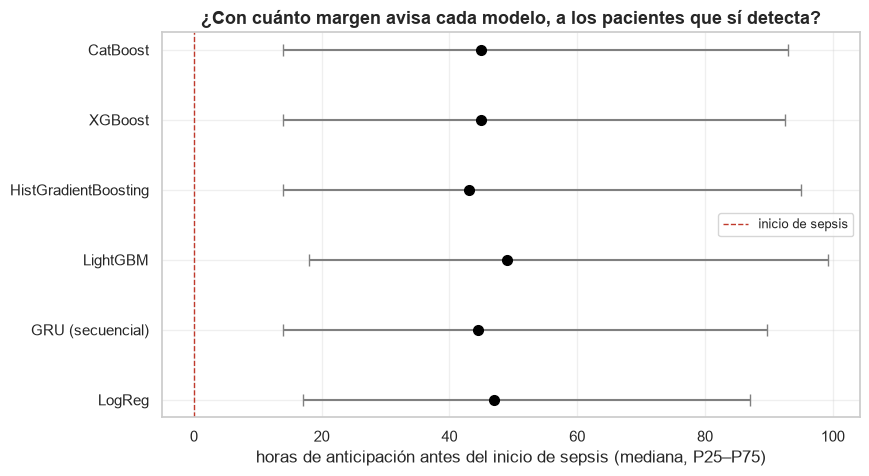

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(panel))
ax.errorbar(panel["anticipacion_mediana_h"], y,
            xerr=[panel["anticipacion_mediana_h"] - panel["anticipacion_p25_h"],
                  panel["anticipacion_p75_h"] - panel["anticipacion_mediana_h"]],
            fmt="o", color="black", ecolor="gray", capsize=4, ms=7)
ax.set_yticks(y, panel["modelo"])
ax.axvline(0, color=viz.COLOR_SEPSIS, ls="--", lw=1, label="inicio de sepsis")
ax.set_xlabel("horas de anticipación antes del inicio de sepsis (mediana, P25–P75)")
ax.set_title("¿Con cuánto margen avisa cada modelo, a los pacientes que sí detecta?")
ax.legend(fontsize=9)
ax.invert_yaxis()


Entre los pacientes que sí se detectan a tiempo, los seis modelos avisan con una mediana
parecida (43-49 horas antes del inicio) — la brecha de detección de `CatBoost` frente a
`HistGradientBoosting` (Sección 6) no viene de avisar tarde a quienes sí atrapa, viene de
atrapar a menos pacientes distintos en primer lugar. El dato que más llama la atención es
`LightGBM`: no es el mejor en utility ni en detección, pero es **el que más se anticipa** de
los seis cuando sí avisa (mediana de 49,0 h, contra 43,0-47,0 h en el resto, con el P25 más
alto también: 18,0 h). Es el mismo tipo de matiz que ya apareció con la regresión logística en
versiones anteriores de este análisis — un modelo que no lidera ninguna métrica de acierto
puede seguir siendo el más temprano cuando sí acierta, algo que ni AUROC ni utility capturan
directamente porque ninguno de los dos separa "cuántos detecta" de "con cuánto margen avisa a
los que sí detecta". Valdría la pena explorarlo si el objetivo clínico fuera priorizar
anticipación por encima de cobertura.


## 9. ¿El campeón rinde igual en los dos hospitales?

Todo lo anterior mide al campeón sobre el test mezclado (A+B). Pero el notebook 06 ya mostró
que A y B son sistemas distintos —A más grave, B con mejor registro administrativo— y que
`CatBoost` es, de los cinco, el que más consistentemente generaliza al cruzar de hospital. Falta
la pregunta que de verdad le importa a quien va a desplegar esto: **con el modelo y el umbral
ya fijados, ¿el desempeño clínico real es el mismo para un paciente de A que para uno de B?**

Se reparte el mismo `test` (el de toda la sección anterior) por hospital y se recalcula el
panel completo de `evaluacion.evaluar` para cada mitad, **con el mismo umbral de 0,7838** — no
se recalibra por hospital, porque en producción el modelo no sabría de antemano en qué hospital
está corriendo. Esto es distinto del Escenario C del notebook 06 (que compara reentrenar
solo con un hospital contra el modelo mixto): aquí el modelo es el mismo en los dos casos, lo
único que cambia es sobre qué población se mide.

In [12]:
score_campeon = scores[campeon]
filas = []
for h in ["A", "B"]:
    mask = (test["hosp"] == h).to_numpy()
    sub, s = test[mask], score_campeon[mask]
    y = sub["SepsisLabel"].to_numpy()
    r = evaluacion.evaluar(sub, s, cfg, nombre=f"{campeon} — hospital {h}", umbral=umbral_campeon)

    # La columna nativa "sensibilidad_a_5%" recalibraría el umbral por hospital; para juzgar
    # el modelo ya desplegado con el umbral global, se calculan aparte estas dos columnas.
    alarma = s >= umbral_campeon
    r["tasa_alarma_efectiva_%"] = round(alarma.mean() * 100, 3)
    r["sensibilidad_al_umbral_global"] = round(alarma[y == 1].mean(), 4)
    filas.append(r)

panel_por_hospital = pd.DataFrame(filas)
cols_mostrar = ["modelo", "AUPRC", "AUROC", "utility_normalizado", "umbral",
                "tasa_alarma_efectiva_%", "sensibilidad_al_umbral_global",
                "detectados", "no_detectados_antes_del_evento", "anticipacion_mediana_h"]
panel_por_hospital[cols_mostrar].round(4)

,modelo,AUPRC,AUROC,utility_normalizado,umbral,tasa_alarma_efectiva_%,sensibilidad_al_umbral_global,detectados,no_detectados_antes_del_evento,anticipacion_mediana_h
0,CatBoost — hospital A,0.1190,0.8357,0.3724,0.7838,5.913,0.3917,158,171,35.0
1,CatBoost — hospital B,0.1295,0.8605,0.3350,0.7838,4.072,0.3653,79,143,55.0


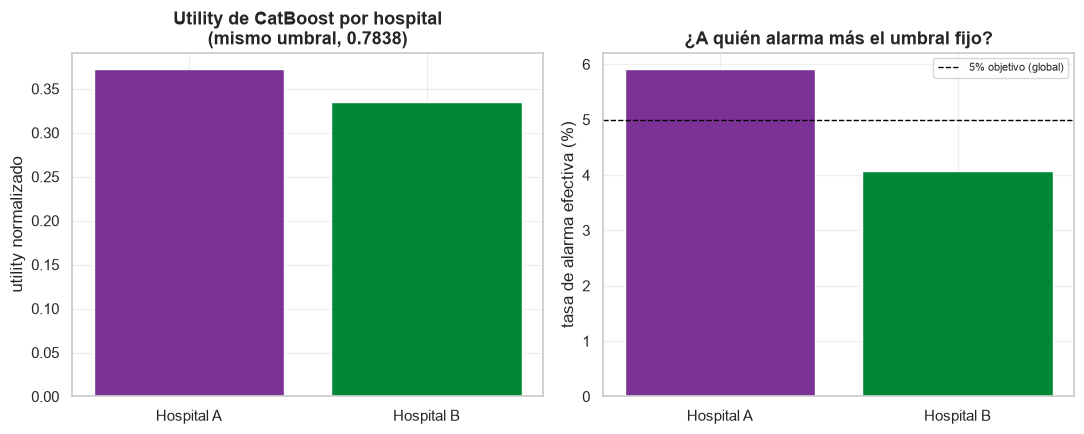

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colores_hosp = [viz.COLOR_A, viz.COLOR_B]

axes[0].bar(["Hospital A", "Hospital B"], panel_por_hospital["utility_normalizado"], color=colores_hosp)
axes[0].set_ylabel("utility normalizado")
axes[0].set_title(f"Utility de {campeon} por hospital\n(mismo umbral, {umbral_campeon:.4f})")

axes[1].bar(["Hospital A", "Hospital B"], panel_por_hospital["tasa_alarma_efectiva_%"], color=colores_hosp)
axes[1].axhline(5, color="black", ls="--", lw=1, label="5% objetivo (global)")
axes[1].set_ylabel("tasa de alarma efectiva (%)")
axes[1].set_title("¿A quién alarma más el umbral fijo?")
axes[1].legend(fontsize=8)
plt.tight_layout()

El resultado invierte lo que el notebook 06 hacía esperar, y por eso vale la pena mirarlo con
cuidado en vez de repetir la misma conclusión con otra métrica.

**Por AUROC/AUPRC, B seguía siendo "mejor"** (AUROC 0,8605 vs. 0,8357; AUPRC 0,1295 vs. 0,1190
— el mismo patrón del notebook 06). **Pero por utility, el que realmente le sirve al clínico, A
gana con claridad: 0,3724 contra 0,3350.** La razón está en la columna
`tasa_alarma_efectiva_%`: el umbral 0,7838 se calibró para alarmar en el 5% de las horas del
test *mezclado*, pero aplicado por separado alarma en **5,91%** de las horas de A y solo
**4,07%** de las de B. Los scores de A están, en conjunto, un poco más altos —coherente con que
A es el hospital clínicamente más grave (notebook 01)—, así que más de sus horas cruzan un
umbral pensado para la mezcla. En la práctica, A recibe un presupuesto de alarma ligeramente
mayor que B con el mismo número, y eso se traduce en detectar al **48,0% de sus sépticos**
(158 de 329) frente a solo **35,6%** en B (79 de 222).

El otro lado de ese mismo mecanismo: cuando B sí detecta, avisa con más margen — mediana de
**55 horas** de anticipación frente a **35 horas** en A. Menos pacientes detectados, pero con
más tiempo de reacción cuando sí se detectan; es la misma clase de compensación entre cobertura
y anticipación que ya apareció al comparar modelos completos en la Sección 5.

**La lectura que hay que llevar a la sustentación no es "el modelo es mejor en A" ni "es mejor
en B" a secas — depende de qué se esté midiendo.** Como *clasificador* (qué tan bien ordena los
scores), rinde mejor en B. Como *sistema de alarma ya desplegado con un umbral fijo*, sirve
mejor en A, porque el mismo umbral global termina siendo, sin proponérselo, un poco más
generoso con A. Es un argumento más para no prometer un desempeño uniforme entre hospitales: ni
siquiera "mejor" o "peor" es una sola respuesta, cambia según qué pregunta se haga.

**`CatBoost` queda como modelo campeón definitivo**, con utility normalizado de 0,3575 en el
punto de operación real y un umbral de decisión de **0,7838** — ya no "provisional" como quedó
en el notebook 06, sino elegido con la métrica que de verdad importa para desplegarlo.

Guardamos el panel completo — no solo el nombre del ganador — porque el notebook 08 va a
necesitar el umbral elegido y las métricas de cada modelo para la interpretabilidad, sin tener
que recalcular los scores.

In [14]:
destino = cfg["rutas"]["models"] / "resultados_utility_umbral.csv"
panel.to_csv(destino, index=False)
print(f"Guardado en {destino.relative_to(cfg['raiz'])}")


Guardado en models\resultados_utility_umbral.csv


## 10.1 ¿Qué tan bueno es un utility de 0,3575? El challenge real como vara de medir

Un número aislado no dice si 0,3575 es un buen resultado. Lo comparamos contra la fuente que
sí importa: los resultados oficiales del propio PhysioNet/CinC Challenge 2019
([Reyna et al. 2019](https://www.cinc.org/archives/2019/pdf/CinC2019-412.pdf), el paper de
los organizadores), no una intuición sobre qué número "debería" verse bien.

El challenge oficial recibió 853 envíos de 104 equipos y evaluó a los 88 con entradas válidas
sobre un test **oculto** de tres hospitales — los mismos A y B que conocemos, más un
**hospital C que ningún equipo vio jamás**, ni siquiera sin etiquetas. La Tabla 1 de ese paper
reporta los cinco mejores resultados oficiales:

In [15]:
leaderboard_oficial = pd.DataFrame([
    {"rank": 1, "equipo": "Morrill et al.", "final": 0.360, "score_A": 0.433, "score_B": 0.434, "score_C": -0.123},
    {"rank": 2, "equipo": "Du et al.", "final": 0.345, "score_A": 0.409, "score_B": 0.396, "score_C": -0.042},
    {"rank": 3, "equipo": "Zabihi et al.", "final": 0.339, "score_A": 0.422, "score_B": 0.395, "score_C": -0.146},
    {"rank": 4, "equipo": "Li et al.", "final": 0.337, "score_A": 0.420, "score_B": 0.401, "score_C": -0.156},
    {"rank": 5, "equipo": "Singh et al.", "final": 0.337, "score_A": 0.401, "score_B": 0.407, "score_C": -0.094},
]).set_index("rank")
leaderboard_oficial

,equipo,final,score_A,score_B,score_C
rank,,,,,
1,Morrill et al.,0.360,0.433,0.434,-0.123
2,Du et al.,0.345,0.409,0.396,-0.042
3,Zabihi et al.,0.339,0.422,0.395,-0.146
4,Li et al.,0.337,0.420,0.401,-0.156
5,Singh et al.,0.337,0.401,0.407,-0.094


La comparación justa no es contra la columna "final" — esa mezcla el desempeño en A y B con
el desplome en C, un hospital que ni siquiera nosotros tenemos disponible para probar. Lo
comparable es contra **Score A / Score B**, la parte del test oficial construida con
hospitales del mismo tipo que los nuestros.

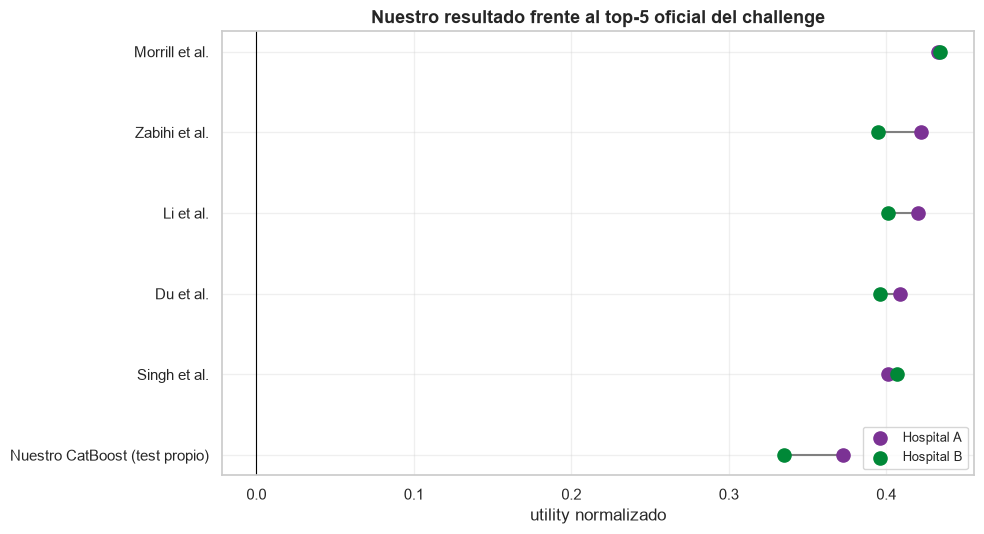

In [16]:
comparacion_challenge = pd.concat([
    leaderboard_oficial.reset_index()[["equipo", "score_A", "score_B"]],
    pd.DataFrame([{"equipo": "Nuestro CatBoost (test propio)",
                   "score_A": panel_por_hospital.iloc[0]["utility_normalizado"],
                   "score_B": panel_por_hospital.iloc[1]["utility_normalizado"]}]),
], ignore_index=True).sort_values("score_A")

fig, ax = plt.subplots(figsize=(10, 5.5))
y = np.arange(len(comparacion_challenge))
for yi, fila in zip(y, comparacion_challenge.itertuples()):
    ax.plot([fila.score_A, fila.score_B], [yi, yi], color="grey", lw=1.5, zorder=1)
ax.scatter(comparacion_challenge["score_A"], y, color=viz.COLOR_A, s=90, label="Hospital A", zorder=2)
ax.scatter(comparacion_challenge["score_B"], y, color=viz.COLOR_B, s=90, label="Hospital B", zorder=2)
ax.set_yticks(y, comparacion_challenge["equipo"])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("utility normalizado")
ax.set_title("Nuestro resultado frente al top-5 oficial del challenge")
ax.legend(fontsize=9)
plt.tight_layout()

Nuestro resultado (0,3724 en A, 0,3350 en B) queda **dentro del rango del top-5 oficial**
(0,40-0,43 en A, 0,40-0,43 en B) — un poco por debajo, pero en el mismo orden de magnitud que
equipos que compitieron en un challenge internacional con cientos de participantes. La
comparación no es perfecta —ellos entrenaron con más datos disponibles en su momento y
compitieron por el premio; nosotros no tenemos acceso al hidden set real—, pero sitúa nuestro
número en su contexto correcto: no es un resultado débil, es del orden de lo que la propia
comunidad de investigación consigue en este problema exacto.

Y hay un hallazgo en esa misma tabla que vale más que la comparación de nuestro propio
número: **los cinco mejores equipos del mundo, sin excepción, sacan utility NEGATIVO en el
hospital C** —el que nunca vieron, ni con etiquetas ni sin ellas—. El propio equipo ganador
cae de 0,433/0,434 en A/B a **−0,123** en C: peor que no alertar nunca a nadie. No es un
matiz menor, es la confirmación, con la evidencia más fuerte disponible (el ganador mundial
del challenge, no nuestro propio experimento), de exactamente lo que encontramos en el
notebook 06: cruzar de hospital en la predicción de sepsis es un problema que ni los mejores
equipos del planeta han resuelto — no una limitación de este pipeline en particular.

## 11. Qué sabemos al cerrar este notebook

- **`CatBoost` es el campeón definitivo**: utility normalizado de 0,3575 en el punto de
  operación real (alarma ≤ 5% de las horas), el mejor de los seis — confirma, ya con la
  métrica correcta y no solo con AUROC, la elección provisional del notebook 06.
- **El AUPRC no predice el orden real**: `XGBoost` tenía peor AUPRC que `HistGradientBoosting`
  en el notebook 06 (0,1127 vs 0,1144) y aun así lo supera en utility (0,3472 vs 0,3385) en
  casi todo el rango de presupuestos de alarma — evidencia de que el momento del acierto, no
  solo el orden de los scores, cambia el ranking.
- **El precio real del campeón, en horas concretas**: al 5% de alarma, `CatBoost` genera
  13.550 falsas alarmas por 2.000 aciertos (cerca de 6,8 a 1) — una ROC casi idéntica entre
  los seis modelos (AUROC 0,80-0,85) escondía esta diferencia; la curva Precision-Recall y la
  matriz de confusión (Secciones 4 y 7) la hacen visible.
- **Ganar en utility no significa detectar a más pacientes**: `CatBoost` detecta a tiempo
  solo al 43,0% de los sépticos del test (237/551), menos que `HistGradientBoosting` (47,7%,
  263/551) — pero captura más horas sépticas en total (38,1% vs 36,7% de sensibilidad) porque
  su umbral más alto (0,784 vs 0,722) concentra las alarmas en menos pacientes, con más horas
  seguidas cada uno. El utility score, al sumar por hora, premia esa concentración.
- **"Mejor" depende de qué se mida, y de para quién: el mismo modelo con el mismo umbral
  rinde distinto en A que en B, y no en la misma dirección según la métrica.** Como
  clasificador (AUROC/AUPRC), es mejor en B (0,8605/0,1295 vs. 0,8357/0,1190 en A, notebook
  06). Pero como sistema de alarma ya desplegado, es mejor en A: utility 0,3724 vs. 0,3350,
  con 48,0% de sus sépticos detectados (158/329) frente a 35,6% en B (79/222). La causa: el
  umbral único (0,7838), calibrado sobre la mezcla, alarma en 5,91% de las horas de A pero
  solo 4,07% de las de B — sin proponérselo, le da a A un presupuesto de alarma algo mayor.
  Cuando B sí detecta, avisa con más margen (mediana 55h vs. 35h en A) — menos cobertura, más
  anticipación. Ninguna respuesta de una sola palabra ("mejor en A" o "mejor en B") es
  correcta sin decir contra qué métrica se está comparando.
- **Nuestro resultado está en el mismo orden de magnitud que el top-5 oficial del challenge**
  (Sección 10.1) — y el hallazgo más contundente no es nuestro: los cinco mejores equipos del
  mundo sacan utility negativo en el hospital nunca visto (hasta −0,123 el ganador). Cruzar de
  hospital en sepsis es un problema abierto a nivel de toda la comunidad, no una limitación de
  este pipeline.
- **Ningún modelo alcanza su pico de utility en el presupuesto de alarma real** (todos siguen
  subiendo más allá del 5%) — la elección del umbral no es "buscar el mejor número", es
  aceptar el mejor resultado dentro de una restricción operativa real.
- **`LightGBM`, sin ser el mejor en ninguna métrica de acierto, avisa más temprano cuando sí
  detecta** (mediana de 49,0 h vs 43,0-47,0 h en el resto) — un matiz que ni AUROC ni utility
  capturan directamente.

➡️ Siguiente: `08_interpretabilidad.ipynb` — qué variables está usando realmente el modelo
campeón para confiar (o no) en él más allá de sus métricas.